In [1]:
from multicam_recorder import MultiCameraRecorder
from video_synchronizer import VideoSynchronizer
import time
from datetime import datetime

In [14]:
# 1. Setup recorder
recorder = MultiCameraRecorder(
    camera_ids=[0, 1, 2, 3],  # Your cameras
    fps=30
)

data_dir = '/Users/robertseymour/Documents/recordings/'


INFO:multicam_recorder:MultiCameraRecorder initialized with cameras: [0, 1, 2, 3]


In [15]:
# 2. Connect to cameras (once)
recorder.connect_cameras()

INFO:multicam_recorder:Connecting to camera 0...
INFO:multicam_recorder:Camera 0 (Camera 0): 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 1...
INFO:multicam_recorder:Camera 1 (Camera 1): 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 2...
INFO:multicam_recorder:Camera 2 (Camera 2): 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 3...
INFO:multicam_recorder:Camera 3 (Camera 3): 1280x720 @ 30fps
INFO:multicam_recorder:Connected to 4/4 cameras


{0: True, 1: True, 2: True, 3: True}

In [6]:
recorder.preview_cameras(duration=15.0,target_fps=30)

INFO:multicam_recorder:Showing preview for 15.0s at ~30fps (press 'q' to quit)...
INFO:multicam_recorder:Preview resolution: 640x360 (50% of original)


In [16]:
# 3. Record Trial 1
# Get current timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H_%M_%S")

recorder.start_recording(data_dir+'recording_' + timestamp)
time.sleep(60)  # Record for 10 seconds
recorder.stop_recording()

INFO:multicam_recorder:Starting recording: /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36
INFO:multicam_recorder:Camera 0 recording to /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/raw_videos/camera_0.avi
INFO:multicam_recorder:Camera 1 recording to /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/raw_videos/camera_1.avi
INFO:multicam_recorder:Camera 2 recording to /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/raw_videos/camera_2.avi
INFO:multicam_recorder:Camera 3 recording to /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/raw_videos/camera_3.avi
INFO:multicam_recorder:Recording started on 4 cameras
INFO:multicam_recorder:Stopping recording...
INFO:multicam_recorder:Camera 0 stopped recording: 1769 frames
INFO:multicam_recorder:Camera 1 stopped recording: 1805 frames
INFO:multicam_recorder:Camera 2 stopped recording: 1776 frames
INFO:multicam_recorder:Camera 3 stopped rec

{0: (1769,
  [1770741636.9319968,
   1770741636.981303,
   1770741636.999669,
   1770741637.031915,
   1770741637.065303,
   1770741637.0980659,
   1770741637.1310332,
   1770741637.163755,
   1770741637.196438,
   1770741637.262489,
   1770741637.2956438,
   1770741637.3278332,
   1770741637.3612978,
   1770741637.3938181,
   1770741637.427016,
   1770741637.459925,
   1770741637.4929469,
   1770741637.525506,
   1770741637.5599449,
   1770741637.5922592,
   1770741637.625362,
   1770741637.657994,
   1770741637.692319,
   1770741637.724274,
   1770741637.757867,
   1770741637.7912,
   1770741637.823959,
   1770741637.856607,
   1770741637.890003,
   1770741637.923305,
   1770741637.955897,
   1770741637.989134,
   1770741638.0222878,
   1770741638.05523,
   1770741638.0887418,
   1770741638.120949,
   1770741638.154808,
   1770741638.187668,
   1770741638.219393,
   1770741638.254032,
   1770741638.286261,
   1770741638.319747,
   1770741638.351524,
   1770741638.387198,
   177074163

In [17]:
# 5. Disconnect
recorder.disconnect_cameras()

INFO:multicam_recorder:Disconnecting cameras...
INFO:multicam_recorder:Stopping camera 0...
INFO:multicam_recorder:Camera 0 stopped successfully
INFO:multicam_recorder:Stopping camera 1...
INFO:multicam_recorder:Camera 1 stopped successfully
INFO:multicam_recorder:Stopping camera 2...
INFO:multicam_recorder:Camera 2 stopped successfully
INFO:multicam_recorder:Stopping camera 3...
INFO:multicam_recorder:Camera 3 stopped successfully
INFO:multicam_recorder:All cameras disconnected successfully


In [7]:
from sync_by_timestamps import synchronize_videos_to_ideal_fps
from plot_sync_results import plot_sync_results, plot_sync_summary_stats


In [ ]:
# Synchronize all videos to camera 0
trial_dir = data_dir+'recording_' + timestamp

# Synchronize to ideal 30 FPS (or whatever you specify)
results = synchronize_videos_to_ideal_fps(
    trial_folder=trial_dir,
    target_fps=30.0,  # Your target FPS
    max_time_diff_ms=50.0
)


Timestamp-based Synchronization to Ideal 30.0 FPS Clock
Trial folder: /Users/robertseymour/Documents/recordings/recording_20260210_16_26_05
Raw videos:   /Users/robertseymour/Documents/recordings/recording_20260210_16_26_05/raw_videos
Output dir:   /Users/robertseymour/Documents/recordings/recording_20260210_16_26_05/synchronized_videos
Target FPS:   30.0

[1] Loading timestamps...
  Camera 2: 1183 timestamps, range: [1770740765.675, 1770740805.771]s
  Camera 3: 1185 timestamps, range: [1770740765.662, 1770740805.920]s
  Camera 1: 1202 timestamps, range: [1770740765.654, 1770740805.716]s
  Camera 0: 1180 timestamps, range: [1770740765.662, 1770740805.656]s

[2] Finding global time range...
  Global start time: 1770740765.675s
  Global end time:   1770740805.656s
  Duration:          39.980s

[3] Creating ideal 30.0 FPS timing grid...
  Ideal frame count: 1200
  Ideal duration:    39.967s

[4] Finding video files...
  Camera 0: camera_0.avi
  Camera 1: camera_1.avi
  Camera 2: camera_2


📊 Plots saved to: /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/synchronization_plots/sync_analysis.png
📊 PDF saved to: /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/synchronization_plots/sync_analysis.pdf


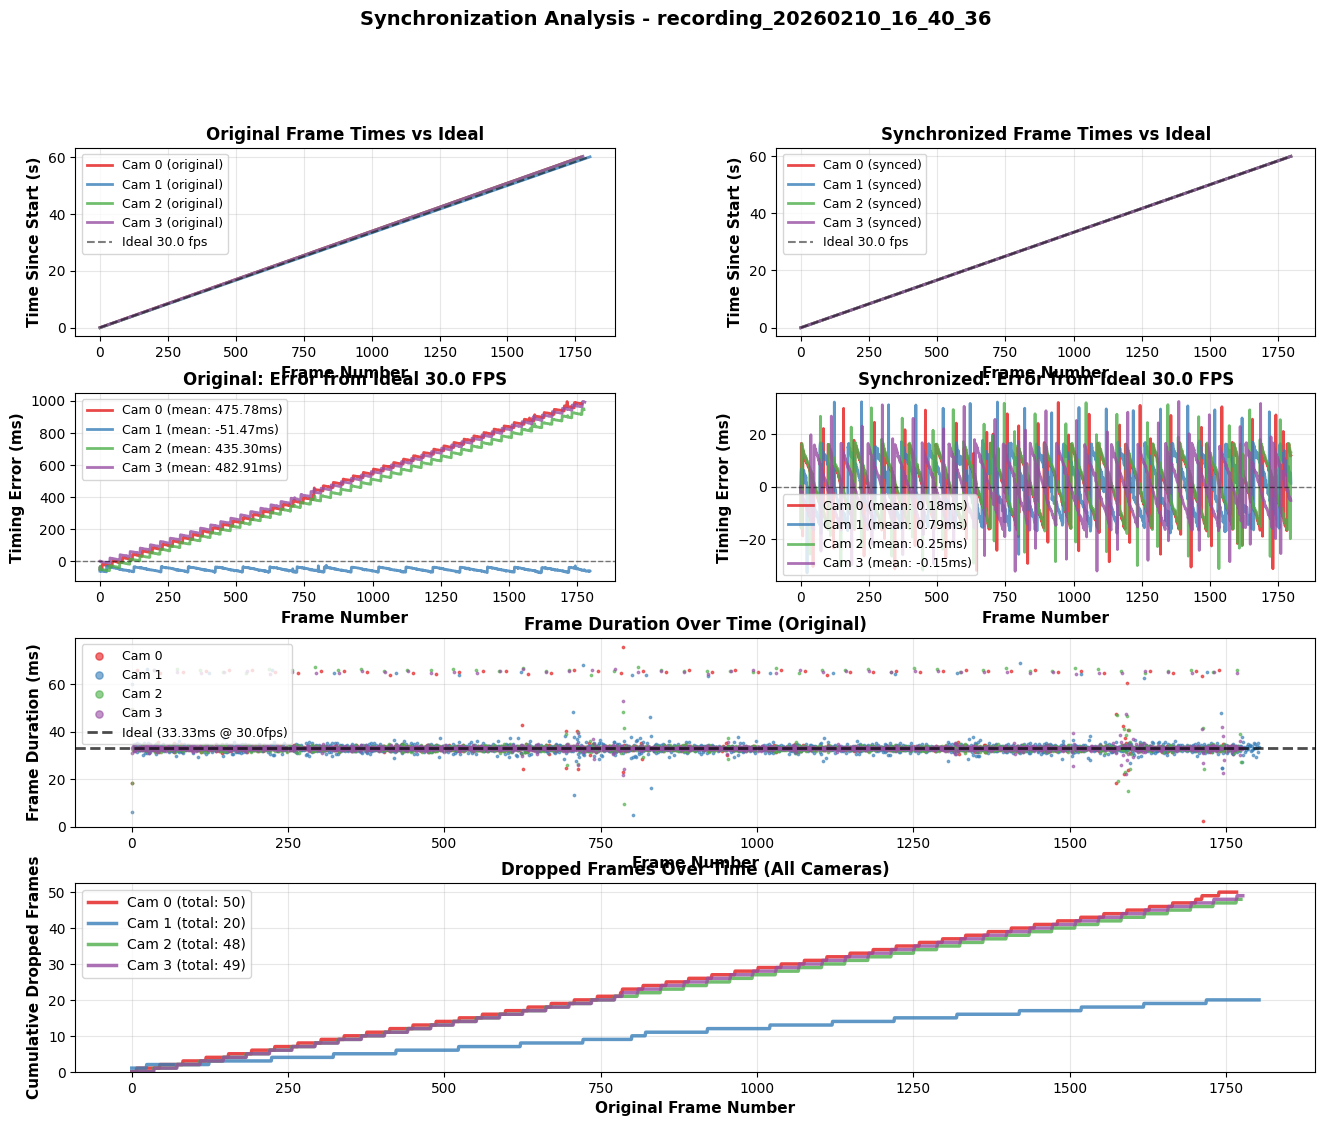

📊 Summary plots saved to: /Users/robertseymour/Documents/recordings/recording_20260210_16_40_36/synchronization_plots/sync_summary.png


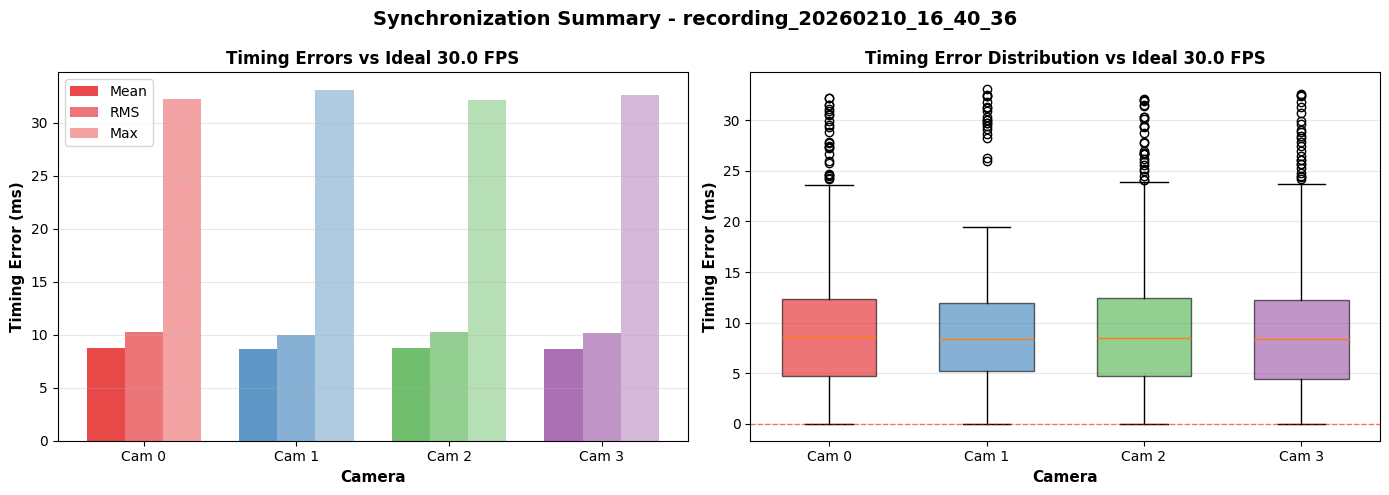

In [20]:
# Create plots
figs = plot_sync_results(
    results=results,
    trial_folder=trial_dir,
    save_plots=True,
    show_plots=True
)

# Summary stats
fig_summary = plot_sync_summary_stats(
    results=results,
    trial_folder=trial_dir,
    save_plots=True
)

In [12]:
from pathlib import Path
import math

import cv2
import numpy as np


def save_synced_videos_tiled(
    trial_folder,
    synced_subdir="synchronized_videos",
    out_name="synchronized_tiled.mp4",
    max_cols=3,
    max_width=1920,
    pad_px=6,
    pad_value=0,  # black padding
    font_scale=0.9,
    thickness=2,
):
    """
    Tile synchronized videos into a single review video (grid layout).

    - Auto-wrap: up to `max_cols` per row (default 3), then starts a new row.
    - Assumes synchronized and identical frame counts (still checks).
    - Input filenames: camera_<id>_synchronized.mp4

    Output is MP4 (H.264 if available, else mp4v).
    """
    trial_folder = Path(trial_folder)
    synced_dir = trial_folder / synced_subdir
    out_path = trial_folder / out_name

    videos = sorted(synced_dir.glob("camera_*_synchronized.mp4"))
    if not videos:
        raise FileNotFoundError(f"No synchronized videos found in {synced_dir}")

    caps = []
    cam_ids = []
    for v in videos:
        cap = cv2.VideoCapture(str(v))
        if not cap.isOpened():
            raise RuntimeError(f"Could not open {v}")
        caps.append(cap)
        cam_ids.append(int(v.stem.split("_")[1]))

    # --- checks ---
    frame_counts = [int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) for cap in caps]
    if len(set(frame_counts)) != 1:
        raise ValueError(f"Frame count mismatch: {dict(zip(cam_ids, frame_counts))}")

    fps = caps[0].get(cv2.CAP_PROP_FPS) or 25.0
    n_frames = frame_counts[0]

    # Determine a common cell size (max width/height across cameras)
    widths = [int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) for cap in caps]
    heights = [int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) for cap in caps]
    cell_w = max(widths)
    cell_h = max(heights)

    n = len(caps)
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)

    grid_w = cols * cell_w + (cols - 1) * pad_px
    grid_h = rows * cell_h + (rows - 1) * pad_px

    # Optional downscale to fit screen width
    scale = 1.0
    if max_width and grid_w > max_width:
        scale = max_width / grid_w

    out_w = int(round(grid_w * scale))
    out_h = int(round(grid_h * scale))

    # Choose codec: try H.264 first (often works as 'avc1' on mac, 'H264' on some builds)
    def _make_writer(codec):
        fourcc = cv2.VideoWriter_fourcc(*codec)
        w = cv2.VideoWriter(str(out_path), fourcc, fps, (out_w, out_h))
        return w

    writer = _make_writer("avc1")
    if not writer.isOpened():
        writer = _make_writer("H264")
    if not writer.isOpened():
        writer = _make_writer("mp4v")
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out_path}")

    print("Writing tiled video:")
    print(f"  cameras: {cam_ids}")
    print(f"  videos:  {n} -> grid {rows}x{cols}")
    print(f"  frames:  {n_frames}")
    print(f"  fps:     {fps:.2f}")
    print(f"  cell:    {cell_w}x{cell_h} px")
    print(f"  output:  {out_path}")

    # Reset all captures to frame 0
    for cap in caps:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # --- write ---
    for i in range(n_frames):
        # Start with a blank grid canvas
        canvas = np.full((grid_h, grid_w, 3), pad_value, dtype=np.uint8)

        for idx, (cam_id, cap) in enumerate(zip(cam_ids, caps)):
            ok, frame = cap.read()
            if not ok:
                raise RuntimeError(f"Failed reading frame {i} from camera {cam_id}")

            # Resize into cell (letterbox to preserve aspect ratio)
            fh, fw = frame.shape[:2]
            s = min(cell_w / fw, cell_h / fh)
            new_w = int(round(fw * s))
            new_h = int(round(fh * s))
            resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

            cell = np.full((cell_h, cell_w, 3), pad_value, dtype=np.uint8)
            y0 = (cell_h - new_h) // 2
            x0 = (cell_w - new_w) // 2
            cell[y0:y0 + new_h, x0:x0 + new_w] = resized

            # overlay text (on the cell)
            cv2.putText(
                cell,
                f"Cam {cam_id} | frame {i}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (0, 255, 0),
                thickness,
                cv2.LINE_AA,
            )

            r = idx // cols
            c = idx % cols
            top = r * (cell_h + pad_px)
            left = c * (cell_w + pad_px)
            canvas[top:top + cell_h, left:left + cell_w] = cell

        # Final scale (if needed)
        if scale != 1.0:
            canvas = cv2.resize(canvas, (out_w, out_h), interpolation=cv2.INTER_AREA)

        writer.write(canvas)

    # cleanup
    writer.release()
    for cap in caps:
        cap.release()

    print("Done ✅")
    return out_path


In [15]:
# ---- usage ----
out_video = save_synced_videos_tiled(trial_dir)
out_video

Writing tiled video:
  cameras: [0, 1, 2, 3]
  videos:  4 -> grid 2x3
  frames:  599
  fps:     30.00
  cell:    1280x720 px
  output:  /Users/robertseymour/Documents/recordings/recording_20260210_16_04_07/synchronized_tiled.mp4
Done ✅


PosixPath('/Users/robertseymour/Documents/recordings/recording_20260210_16_04_07/synchronized_tiled.mp4')